# Week3 assignment 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [3]:
df = pd.read_csv("data 201/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,1500000,1280.741760,1.0,Suburb,Townhouse
1,100002,1500000,1406.283113,2.0,Uptown,SingleFamily
2,100003,1500000,4146.825713,6.0,Suburb,MultiFamily
3,100004,1500000,3946.599818,6.0,Suburb,SingleFamily
4,100005,1500000,1243.751760,1.0,Downtown,MultiFamily


In [4]:
df.dtypes

listing_id        int64
price             int64
size            float64
bedrooms        float64
neighborhood     object
type             object
dtype: object

In [5]:
df['size']=df['size'].astype('float')
df['bedrooms']=df['bedrooms'].astype('float')

df.dtypes

listing_id        int64
price             int64
size            float64
bedrooms        float64
neighborhood     object
type             object
dtype: object

In [6]:
df.isna().sum()

listing_id       0
price            0
size            53
bedrooms        24
neighborhood     0
type             0
dtype: int64

In [7]:
df['size'].fillna(df['size'].mean(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].mode()[0], inplace=True)

/tmp/ipykernel_133/3819065639.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size'].fillna(df['size'].mean(), inplace=True)
/tmp/ipykernel_133/3819065639.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [8]:
df.isna().sum()

listing_id      0
price           0
size            0
bedrooms        0
neighborhood    0
type            0
dtype: int64

## PART1--Data visualization

### A. Scatterplots and Aesthetics 

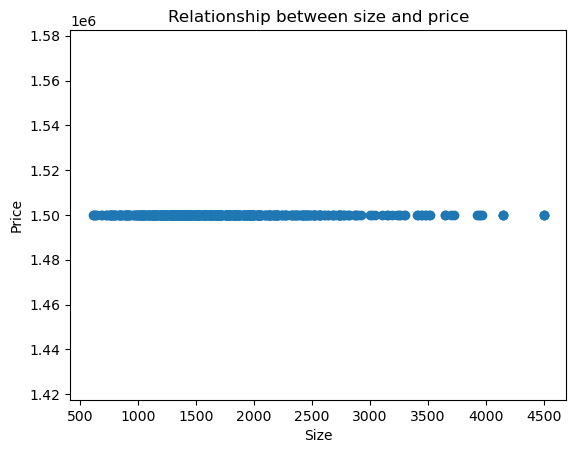

In [9]:
plt.scatter(df['size'],df['price'])
plt.title("Relationship between size and price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

Text(0.5, 1.0, 'Relationship between size and price')

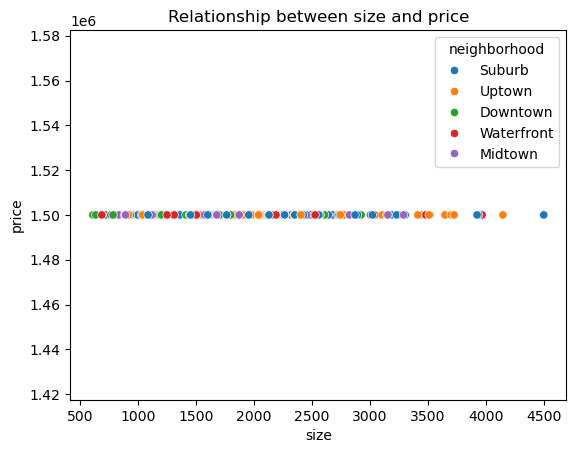

In [10]:
sns.scatterplot(x="size", y="price", data=df, hue="neighborhood")
plt.title("Relationship between size and price")

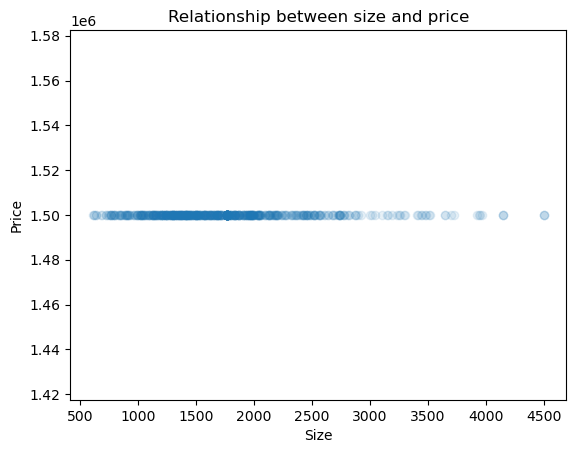

In [11]:
plt.scatter(df['size'],df['price'], alpha=0.1)
plt.title("Relationship between size and price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

 What does seaborn automatically handle that matplotlib does not?
 
Seaborn automatically includes x-label and y-label. In addition, it handles  data visibility via automatic transparency. When seaborn plots multiple data points in the same area, it applies transparency so you can see the density of points rather than just a solid blob.
 
 Why is transparency useful here?
 
  When many data points occupy the same location, a solid marker hides whether there are 2 points or 200 underneath it. Transparency lets the colors stack visually, giving you an honest sense of the distribution without having to switch to a different chart type

### B. Small Multiples (Faceting)

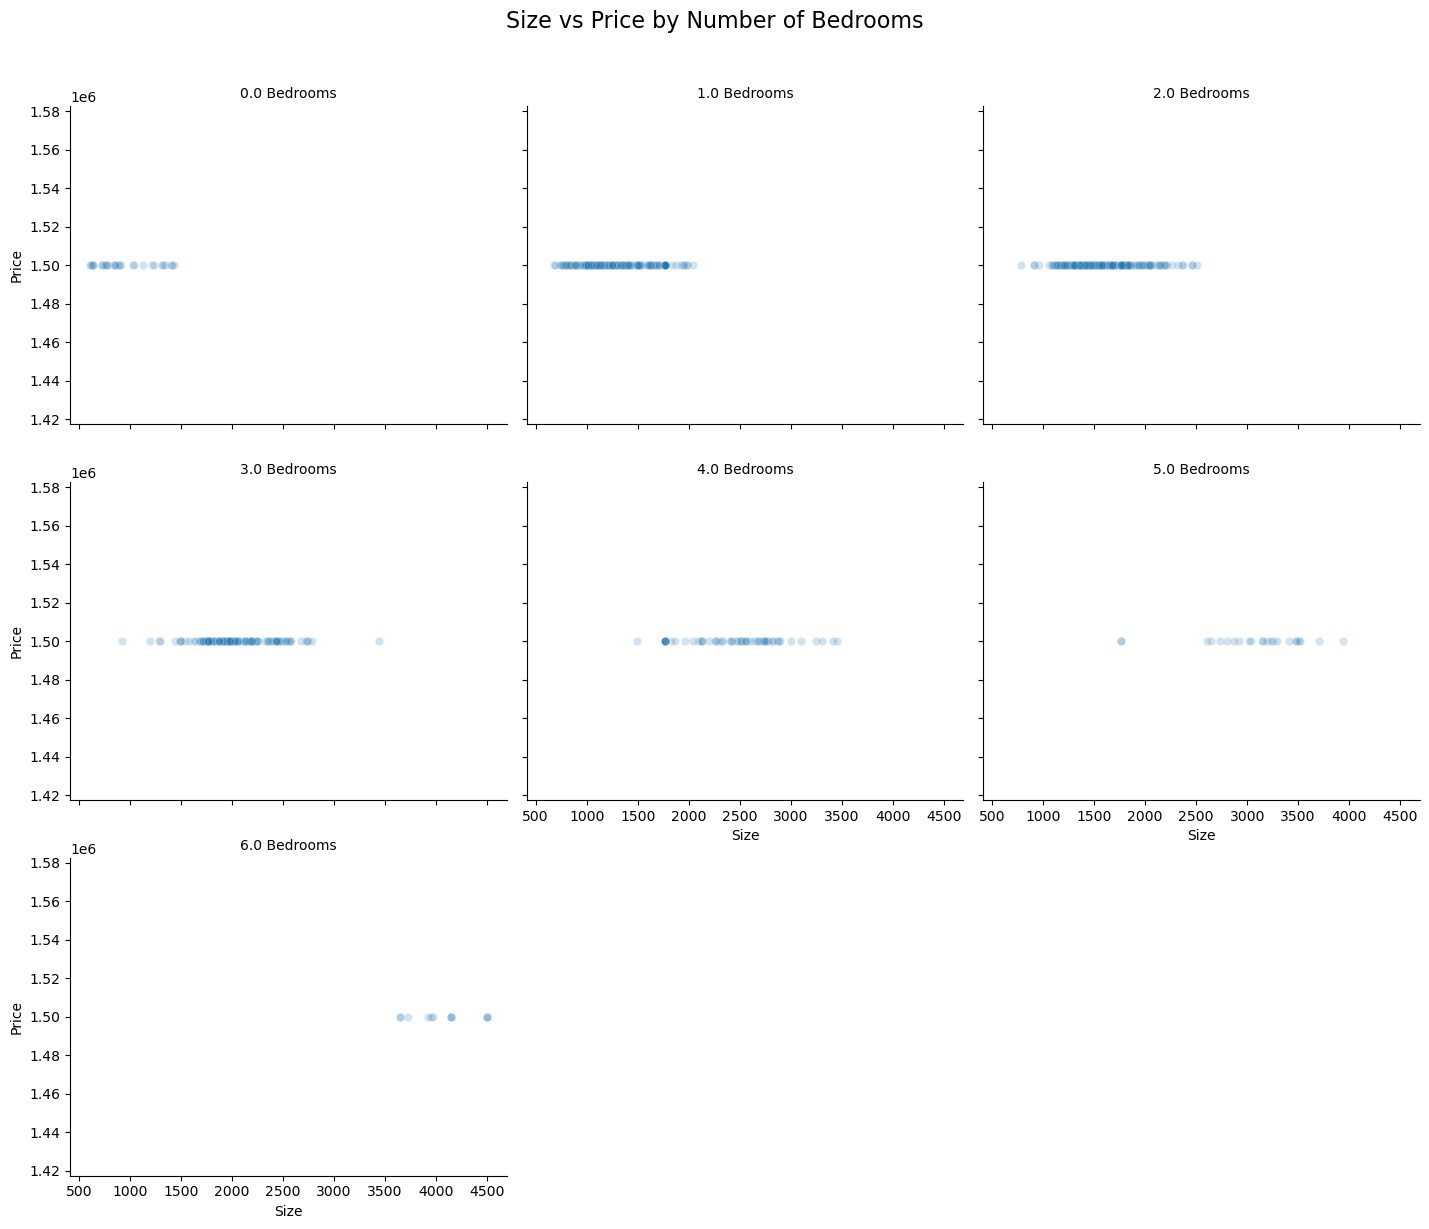

In [12]:
grid = sns.FacetGrid(
    df,
    col="bedrooms",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True,  
    sharex=True
)
grid.map_dataframe(sns.scatterplot, x="size", y="price", alpha=0.2)

grid.set_axis_labels("Size", "Price")
grid.set_titles(col_template="{col_name} Bedrooms")

grid.figure.suptitle("Size vs Price by Number of Bedrooms", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

- Does the relationship between size and price look similar across bedroom
counts?

Yes, the relationship looks similar. Whichever variable we use, the relationship would remain the same because the price never change. It is same regardless of the size of the house or the neighborhood. 


### C. Distribution and Categorical Plots

#### Histogram of price

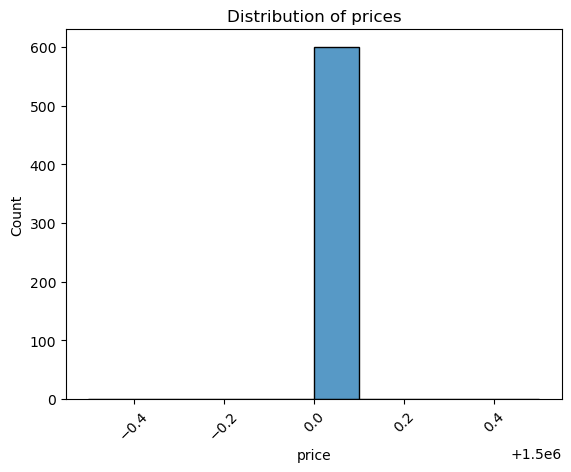

In [13]:
sns.histplot(df['price'], bins=10)
plt.xticks(rotation=45)
plt.title('Distribution of prices')
plt.show()

### Density plot

A kde of price is not quite possible. Variance is needed to create a kde plot, but all values are similar across price.

### boxplot

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Suburb'),
  Text(1, 0, 'Uptown'),
  Text(2, 0, 'Downtown'),
  Text(3, 0, 'Waterfront'),
  Text(4, 0, 'Midtown')])

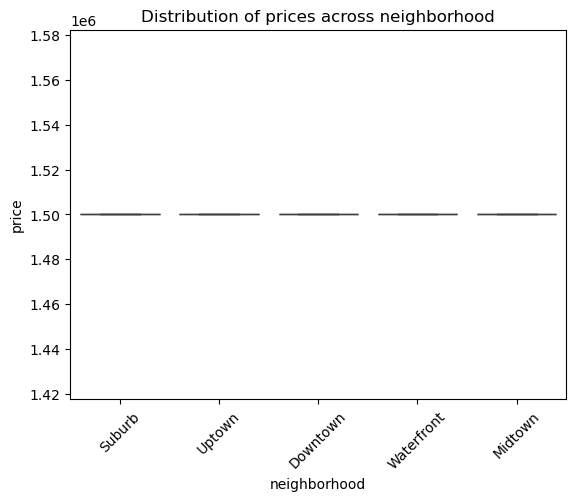

In [14]:
sns.boxplot(x='neighborhood', y='price', data=df)
plt.title("Distribution of prices across neighborhood")
plt.xticks(rotation=45)

 - Do neighborhoods differ systematically in price?
   
No, neighborhoods do not differ in price. 
-   What visual evidence supports your claim?
  
The boxplot suports that evidence because the distribution is the same across all neighborhoods, showing similar median price, similar range, similar quartiles, no outliers across all of them.

## PART B--Linear regression

In [15]:
import statsmodels.formula.api as sm

In [16]:
model = sm.ols('price ~ size + bedrooms + C(neighborhood)', data=df).fit()

In [17]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -98.83
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               1.00
Time:                        03:33:09   Log-Likelihood:                 8846.1
No. Observations:                 600   AIC:                        -1.768e+04
Df Residuals:                     593   BIC:                        -1.765e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Report:

    -   Coefficient estimates
    
    All the predictors return low coefficients which means that they do not significantly impact the outcome of price. This theory is also supported by their p-values. They are very close to 1; they are not statistically significant. 
    
    -   Standard errors: 
    The standard errors are small implying that the estimates are somewhat precise.
    -   R² : 
    The model returned a R^2 of -inf meaning that the model is not performing well. 


### interpretation


1.  Interpret the coefficient on **size**, explicitly stating what is
    being held constant.

    
The model returned a coefficient of 3.263e-11. It means that any change that occurs within size will trigger an increase with a rate of b3.263e-11 in the final price. 

    
3.  Is size statistically significant? How do you know?

Size is statistically significant because its p-value is very close to zero. Also, its standard error is very low implying precision. 
   
5.  What does R² tell us in this context?

R^2 tells us how the model explains the variance in the data. Higher R^2 implies stronger model. 

In [18]:
df.isna().sum()

listing_id      0
price           0
size            0
bedrooms        0
neighborhood    0
type            0
dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Split the data
X = df[["size", "bedrooms"]] 
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Compute metrics on test set
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

RMSE: 0.00
R²:   1.0000


-   Why does scikit-learn not report p-values?

  
    Sklearn does not return a p-value because it is mainly focus on prediction, not statistical inference. It mostly emphasize the predictive performance. 
   
-   Which workflow would you use for:
    -   Explanation?
      For explanation, it is better to use statsmodel because it provides a summary of the metrics needed to understand the model's performance
    -   Prediction?
      For prediction, sklearn is better. 



## PART IV

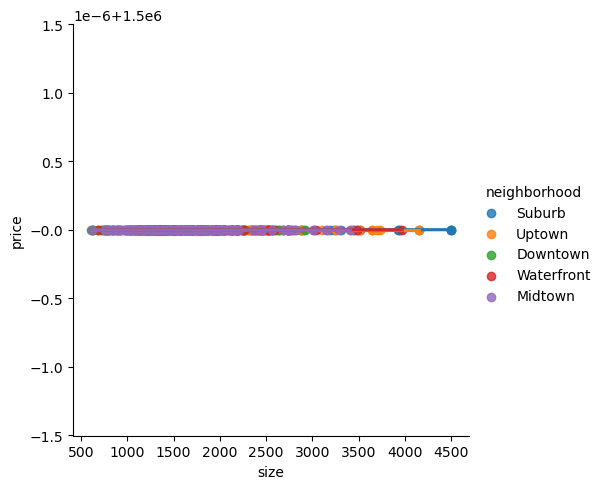

In [20]:
sns.lmplot(x='size', y='price', hue='neighborhood', data=df)
plt.show()

The regression model's perfect R² of 1 and RMSE of 0 technically indicate a flawless fit, which aligns with the perfectly straight line with no deviation between predicted and actual values. However, this perfection is misleading, as the visualization likely revealed that one variable contained identical data points, creating a model that does not reflect true predictive power. The visualization absolutely helped anticipate these suspicious results, because seeing a variable with no spread or variation is an immediate red flag that the model is not genuinely learning a meaningful relationship between the variables. 